In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
from asrl.ogmapping.og_map import OccupancyGridMapper
import matplotlib.pyplot as plt
from time import perf_counter
from spatialmath import SE2, SO2

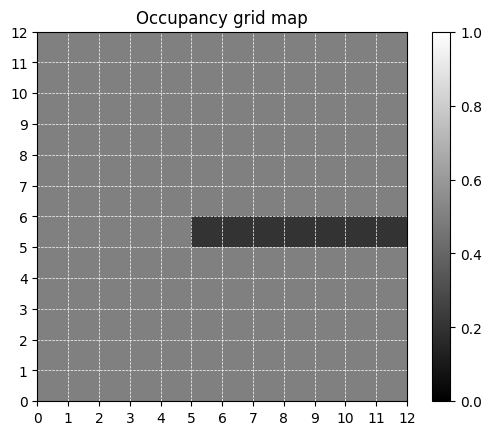

In [9]:
og_mapper = OccupancyGridMapper(resolution=1.0, width_m=10, height_m=10,
                                p_hit=0.9, p_miss=0.2,
                                max_height_px=12,
                                max_width_px=12)

simple_points = np.array([[10.0, 0.0]])
pose = np.array([5.5, 5.5, 0.0])

og_mapper.process_scan(pose, simple_points)
grid_prob = og_mapper.to_prob_map()

res = og_mapper._indexer.resolution
width_cells = og_mapper.grid.shape[1]
height_cells = og_mapper.grid.shape[0]
extent = [0, width_cells * res, 0, height_cells * res]

plt.figure()
plt.imshow(grid_prob, vmin=0, vmax=1,cmap='gray', interpolation='nearest',
           origin='upper', extent=extent)
xticks = np.arange(0, width_cells * res + 0.1, 1.0)
yticks = np.arange(0, height_cells * res + 0.1, 1.0)
plt.xticks(xticks)
plt.yticks(yticks)

plt.grid(which='both', color='white', linestyle='--', linewidth=0.5)
plt.colorbar()
plt.title('Occupancy grid map')
plt.show()

og_mapper.reset()

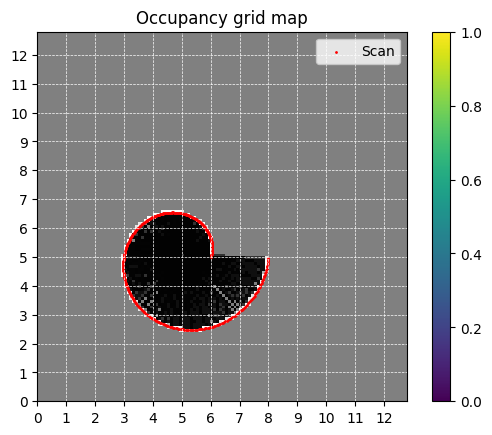

In [11]:
og_mapper = OccupancyGridMapper(resolution=0.1, width_m=10, height_m=10,
                                p_hit=0.9, p_miss=0.2,
                                max_height_px=128,
                                max_width_px=128)

pose = np.array([5, 5, 0])
angles = np.linspace(0, 2*np.pi, 360, endpoint=False)
radii = 1.0 + 2.0 * np.cumsum(np.ones_like(angles)) / len(angles)

cos_theta, sin_theta = np.cos(angles), np.sin(angles)
xs = radii * cos_theta
ys = radii * sin_theta
points = np.stack((xs, ys), axis=-1)

og_mapper.process_scan(pose, points)
grid_prob = og_mapper.to_prob_map()

res = og_mapper._indexer.resolution
width_cells = og_mapper.grid.shape[1]
height_cells = og_mapper.grid.shape[0]
extent = [0, width_cells * res, 0, height_cells * res]

plt.figure()
plt.imshow(grid_prob, vmin=0, vmax=1,cmap='gray', interpolation='nearest',
           origin='upper', extent=extent)

points_world = points + pose[:2]
plt.scatter(points_world[:, 0], points_world[:, 1], c='red', s=1, label='Scan')

xticks = np.arange(0, width_cells * res + 0.1, 1.0)
yticks = np.arange(0, height_cells * res + 0.1, 1.0)
plt.xticks(xticks)
plt.yticks(yticks)

plt.grid(which='both', color='white', linestyle='--', linewidth=0.5)
plt.colorbar()
plt.legend()
plt.title('Occupancy grid map')
plt.show()

og_mapper.reset()

In [12]:
og_mapper = OccupancyGridMapper(resolution=0.1, width_m=10, height_m=10,
                                p_hit=0.9, p_miss=0.2,
                                max_height_px=128,
                                max_width_px=128)

n_trials = 2000
total_time = 0.0
for _ in range(n_trials):
    start = perf_counter()
    og_mapper.process_scan(pose, points)
    total_time += perf_counter() - start
    
    og_mapper.reset()

print(f"Avg. time per scan: {1e3 * total_time / n_trials :.6f} ms")

Avg. time per scan: 0.532551 ms


In [13]:
from asrl.slam_sim.array_map import ArrayMap

env = ArrayMap('/home/dev/workspace/asrl/maps/floorplan1.txt', resolution=1, verbose=True)
height, width = env._walls.shape

og_map = OccupancyGridMapper(0.1, width, height,
                             p_hit=0.9, p_miss=0.2,
                            max_height_px=210,
                            max_width_px=210)

Walls shape: (15, 20), Free space shape: (15, 20)
[[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 1 1 1 1 0 0 1 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 1 0 0 1 0 0 1 0 0 0 1]
 [1 1 0 0 0 1 1 1 0 1 0 0 1 1 1 1 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1]
 [1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 1]
 [1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1]
 [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]]


In [14]:
scan_positions_xy_m = env._indxer.ij_to_xy_m(env._free_space_indices_ij)
n_poses = scan_positions_xy_m.shape[0]

poses = np.zeros((n_poses, 3))
poses[:, :2] = scan_positions_xy_m
poses[:, 2] = np.random.uniform(0, 2 * np.pi, n_poses)

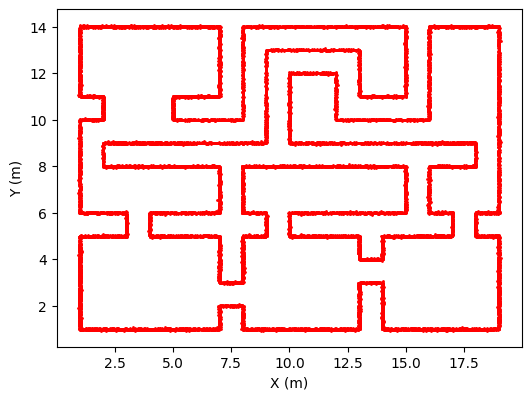

In [15]:
scans = env.raycast_in_map(poses)

fig, ax = plt.subplots(1, 1, figsize=(6, 6))

for i in range(n_poses):
    pose = SE2(poses[i])
    scan_b_B = scans[i]
    scan_w_W = pose * scan_b_B.T
    
    ax.scatter(scan_w_W[0, :], scan_w_W[1, :], c='red', s=1)

ax.set_xlabel('X (m)')
ax.set_ylabel('Y (m)')
ax.set_aspect('equal')
plt.show()

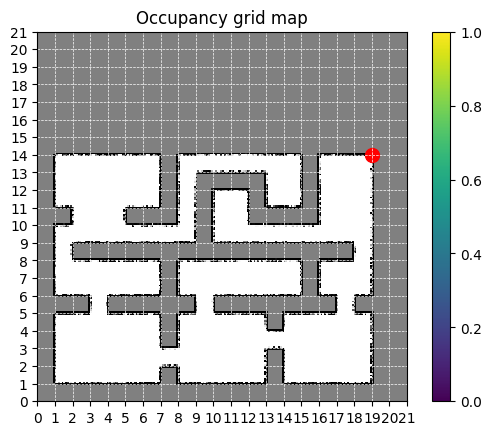

In [16]:
og_map.reset()

for i in range(n_poses):
    og_map.process_scan(poses[i], scans[i])
    
grid_prob = og_map.to_prob_map()

res = og_map._indexer.resolution
width_cells = og_map.grid.shape[1]
height_cells = og_map.grid.shape[0]
extent = [0, width_cells * res, 0, height_cells * res]

plt.figure()
plt.imshow(grid_prob, 
           cmap='gray_r', interpolation='nearest',
           origin='upper', extent=extent)

plt.scatter([19], [14], c='red', s=100, label='Start')

xticks = np.arange(0, width_cells * res + 0.1, 1.0)
yticks = np.arange(0, height_cells * res + 0.1, 1.0)
plt.xticks(xticks)
plt.yticks(yticks)

plt.grid(which='both', color='white', linestyle='--', linewidth=0.5)
plt.colorbar()
plt.title('Occupancy grid map')
plt.show()